In [11]:
import sys
from pathlib import Path
E9path = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\flat_band_cooling\tenpy_results")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))

import util_match
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [12]:
bool_plot = True   # set to false if gathering matching data

# Reading data
In case that we get different EoS using the same folder parameters in the future, I'll also keep track of the EoS file. For this I think the file modification time is sufficient.

Unfinished runs are detected by mismatches in the length of beta.

We are currently not planning to run simulation for kagome lattice because it is too expensive.

How I treat folder parameters:
* $\mu$, $V$, $t_p$ and $shift$ are things we expect to be different in a folder. All the other parameters should be the same; I include them in `folder_params_shared` and check for every folder.
    * Among them, $\mu$ is additionally saved in `data_in_measurements["mu"]`. I check that this indeed matches the one specified in the folder name.
    * For $V$, $t_p$ and $shift$, I don't do the filtering until all the data are loaded.
* I assume $t = 1$.

In [13]:
# I had to keep the data files in the download folder, otherwise the folder names are too long
data_folder = Path(r"C:\Users\ken92\Downloads\Shao-Wen Data")
# Interacting
geometry = "sawtooth" # "sawtooth", "kagome"
L_subregion = 50
chi_tenpy = 64
V_model = 0.3

# geometry specific parameters
tp_ST = 1.41421356237
shift_ST = -2.0

scan_name = f"ST_SL_I_L{L_subregion}_t1_tpsqrt2_shf{int(shift_ST)}_V{V_model}_chi{chi_tenpy}.tar"

In [14]:
N_sites = 2 * L_subregion
E_flat_ST = 2. + shift_ST   # energy of the flat band with shift (noninteracting; assuming ymax is None)
E_min = min(E_flat_ST, -4.)
E_max = max(E_flat_ST, 0.)
geom_spec_str = f"V{V_model}_tp{tp_ST}_shift{shift_ST}"
# For checking folder parameter consistency
tnpspc = {
    "geometry": geometry,
    "L": L_subregion,
    "chi": chi_tenpy,
}

Interacting and non-interacting data is stored differently and require different unpacking methods.

In [15]:
folder_params_shared = None
records_EoS = []
scan_folder = Path(data_folder, scan_name)
assert scan_folder.exists()

subfolder_list = [f for f in scan_folder.iterdir() if f.is_dir()]
print(f"found {len(subfolder_list)} folders")

first_betas = None
for i_f, sf_path in enumerate(subfolder_list):
    # Load data and store them as panda data rows
    filepath = Path(sf_path, "measurements.pkl")
    assert filepath.is_file()
    with open(filepath, "rb") as f:
        file_content = pickle.load(f)

    try:
        folder_params = util_match.parse_folder_name(sf_path)
        
        # Check mu consistency between folder name and file
        mu = file_content['mu']
        if not np.isclose(mu, folder_params['mu']):
            raise(ValueError(f"mu_folder = {folder_params['mu']} doesn't agree with mu_file = {mu}"))
        else:
            folder_params.pop("mu")
        
        # Check shared folder parameters
        V = folder_params.pop("V")
        shift = folder_params.pop("shift")
        tp = folder_params.pop("tp")
        if folder_params_shared is None:
            folder_params_shared = folder_params.copy()
            for k, v in tnpspc.items():
                if folder_params_shared[k] != v:
                    raise(ValueError(f"mismatch in tenpy parameter {k}: specified {v}, but {folder_params_shared[k]} from folder"))
        else:
            if folder_params != folder_params_shared:
                print(folder_params)
                print(folder_params_shared)
                raise(ValueError("mismatch in folder parameters"))

        # Save data
        for i_b, beta in enumerate(file_content['betas']):
            S2, n_avg, energy, eps, ov, max_chi, trace, runtime = file_content['data'][i_b, :]
            records_EoS.append({
                "mu": file_content['mu'],
                "beta": beta,
                "S2": S2,           # per site
                "n_avg": n_avg,     # per site
                "energy": energy,   # per site
                "eps": eps,
                "ov": ov,
                "max_chi": max_chi,
                "trace": trace,
                "runtime": runtime,
                "file_mtime": os.path.getmtime(filepath),
                "V": V,
                "shift": shift,
                "tp": tp
            })
    except ValueError as e:
        print(filepath)
        raise(e)

    # Check beta length and print warnings if they don't look right
    if first_betas is None:   # assuming that the first subfolder has the right length of data
        first_betas = file_content['betas']
        continue
    else:
        len_good = (len(file_content['betas']) == len(first_betas))      # length is good
        if len_good: # content is also good
            if np.allclose(file_content['betas'], first_betas):
                continue
    print(f"beta doesn't agree for {filepath}")
    print(f"getting {file_content['betas']}")

df_all_data = pd.DataFrame.from_records(records_EoS)

found 61 folders


## Filter parameters using Dataframe
Currently I only consider joined systems with the same interaction strength everywhere.

### Specify filter parameters

In [16]:
filter_params = {"V": V_model, "shift": shift_ST, "tp": tp_ST}

In [17]:
df_filtered = df_all_data.query(f"(V == {V_model}) & (shift == {shift_ST})")
idx_list = ["mu", "beta"]
df_filtered = df_filtered.set_index(idx_list).sort_index()

# df_filtered

## Plots
Even for finite interaction strengths, we still see a trace of the flat band in the $S_{2, avg}$ plot. For example, for the $V = 1$, shift $= 2$ single layer sawtooth, we see an enhancement in entropy around $\mu = 0.5$. I would have naively guessed that this should happen at $\mu = 0.25$ instead by looking at the completely localized states (CLS):
* The wave function of CLS lives on two neighboring teeth, and has values of $1 / \sqrt(2)$ on the shared A site, and $1 / 2$ on the two B sites.
    * i.e. there's half a particle on the A site and a quarter of a particle each on the B sites
* Each of the link then gets an energy of $1/2 \cdot 1/4 \cdot V = 1/8$.
* There are two links, so the shift in energy for each CLS is $1/8 \cdot 2 = 1/4$.

In [18]:
mu_vals  = df_filtered.index.get_level_values("mu").unique().to_numpy()
beta_vals = df_filtered.index.get_level_values("beta").unique().to_numpy()
n_grid = df_filtered["n_avg"].unstack("beta").loc[mu_vals, beta_vals].to_numpy()    # particle per site
s2_grid = df_filtered["S2"].unstack("beta").loc[mu_vals, beta_vals].to_numpy()      # Renyi 2-entropy per site
e_grid = df_filtered["energy"].unstack("beta").loc[mu_vals, beta_vals].to_numpy()   # energy per site
eps_grid = df_filtered["eps"].unstack("beta").loc[mu_vals, beta_vals].to_numpy()    # sum of all discarded Schmidt values squared
ov_grid = df_filtered["ov"].unstack("beta").loc[mu_vals, beta_vals].to_numpy()      # lower bound for the overlap

In [53]:
T_vals = 1 / beta_vals

C:\Users\ken92\AppData\Local\Temp\ipykernel_51092\3928328635.py:1: RuntimeWarning: divide by zero encountered in divide
  T_vals = 1 / beta_vals


Decided to not show infidelity.

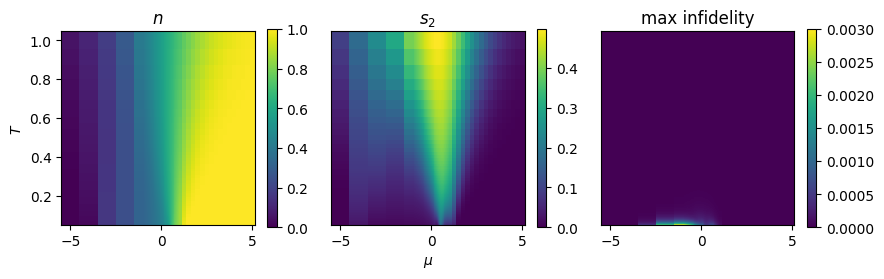

In [61]:
fig_ns, axes_ns = plt.subplots(1, 3, figsize = (9, 2.6))
i_T_clip = 10
for ax, vals, str_label, clim in zip(axes_ns.flatten(),
                    [n_grid, s2_grid, 1 - ov_grid],
                    [r"$n$", r"$s_2$", "max infidelity"],
                    [None, None, (0, 0.003)],):
    T_clip = T_vals[i_T_clip:]
    valsT_clip = (vals[:,i_T_clip:]).T   #transposed
    img = ax.pcolormesh(mu_vals, T_clip, valsT_clip, clim = clim)
    ax.set_box_aspect(1)
    ax.set_title(str_label)
    fig_ns.colorbar(img, ax = ax)
    # cntr = ax.contour(mu_vals, T_clip, valsT_clip, colors = "white", linestyles = "solid", levels = 6)
    # ax.clabel(cntr, inline = True)
    # ax.set_ylim(0, 20)
    # ax.set_xlim(-2, 2)

axes_ns[1].set_xlabel(r"$\mu$")
axes_ns[0].set_ylabel(r"$T$")
axes_ns[1].set_yticks([])
axes_ns[2].set_yticks([])
# fig_ns.suptitle(f"{geometry} lattice, {geom_spec_str}")
fig_ns.tight_layout()

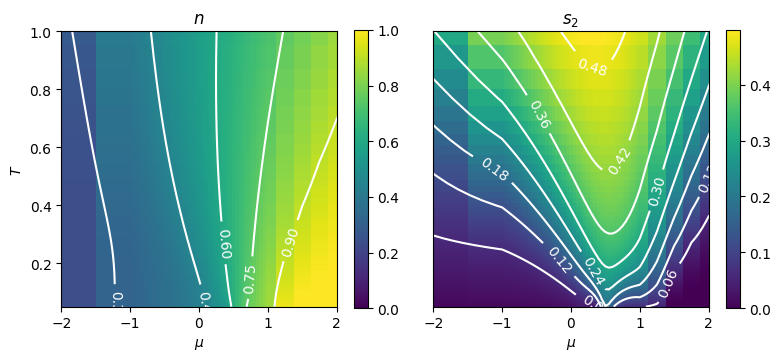

In [81]:
fig, axes = plt.subplots(1, 2, figsize = (8, 3.4))
i_T_clip = 10
for ax, vals, str_label, clim in zip(axes.flatten(),
                    [n_grid, s2_grid],
                    [r"$n$", r"$s_2$"],
                    [None, None]):
    T_clip = T_vals[i_T_clip:]
    valsT_clip = (vals[:,i_T_clip:]).T   #transposed
    img = ax.pcolormesh(mu_vals, T_clip, valsT_clip, clim = clim, rasterized = True)
    ax.set_box_aspect(1)
    ax.set_title(str_label)
    fig.colorbar(img, ax = ax)
    ax.set_xlim(-2, 2)
    ax.set_ylim(T_clip[-1], 1)
    cntr = ax.contour(mu_vals, T_clip, valsT_clip, colors = "white",
                      linestyles = "solid", levels = 8)
    ax.clabel(cntr, inline = True)
    ax.set_xlabel(r"$\mu$")

axes[0].set_ylabel(r"$T$")
axes[1].set_yticks([])
fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_full_path = Path(thesis_fig_path, "ST_EoS_V0.3.pdf")
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')